In [1]:
import os
os.chdir(r'C:\Users\SHIVAM SHAH\Documents')
print(os.listdir())

['.ipynb_checkpoints', 'My Music', 'My Pictures', 'My Videos', 'Netflix.ipynb', 'netflix_titles.csv']


In [2]:
%matplotlib inline

In [3]:
import os
os.chdir(r'C:\Users\SHIVAM SHAH\Documents')
print("Current folder:", os.getcwd())
print("Files:", os.listdir())

Current folder: C:\Users\SHIVAM SHAH\Documents
Files: ['.ipynb_checkpoints', 'My Music', 'My Pictures', 'My Videos', 'Netflix.ipynb', 'netflix_titles.csv']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

NETFLIX_RED  = '#E50914'
NETFLIX_DARK = '#B81D24'
PALETTE = [NETFLIX_RED, '#378ADD', '#1D9E75', '#BA7517', '#534AB7',
           '#D85A30', '#3B6D11', '#993556', '#0F6E56', '#63361A']

sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})
print("All libraries loaded successfully!")

All libraries loaded successfully!


In [5]:
import os
print("Current folder:", os.getcwd())
print("Files here:", os.listdir())

Current folder: C:\Users\SHIVAM SHAH\Documents
Files here: ['.ipynb_checkpoints', 'My Music', 'My Pictures', 'My Videos', 'Netflix.ipynb', 'netflix_titles.csv']


In [6]:
df = pd.read_csv('netflix_titles.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (8807, 12)

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
print("Missing values:\n")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated(subset=['show_id']).sum())

Missing values:

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicates: 0


In [8]:
before = len(df)
df = df.drop_duplicates(subset=['show_id'])
print(f"Removed {before - len(df)} duplicate rows")
print(f"Remaining rows: {len(df)}")

Removed 0 duplicate rows
Remaining rows: 8807


In [9]:
df['director']     = df['director'].fillna('Unknown')
df['cast']         = df['cast'].fillna('Not Available')
df['country']      = df['country'].fillna(df['country'].mode()[0])
df['date_added']   = df['date_added'].fillna('January 01, 2020')
df['rating']       = df['rating'].fillna(df['rating'].mode()[0])
df['duration']     = df['duration'].fillna(df['duration'].mode()[0])
df['release_year'] = df['release_year'].fillna(df['release_year'].median())
df.dropna(subset=['title', 'description'], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [10]:
df['date_added']      = pd.to_datetime(df['date_added'].str.strip(),
                                        format='%B %d, %Y', errors='coerce')
df['year_added']      = df['date_added'].dt.year
df['month_added']     = df['date_added'].dt.month
df['month_name']      = df['date_added'].dt.strftime('%b')
df['release_year']    = df['release_year'].astype(int)
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()
df['primary_genre']   = df['listed_in'].str.split(',').str[0].str.strip()

print("New columns added successfully!")
print(df[['date_added','year_added','month_name',
          'primary_country','primary_genre']].head())

New columns added successfully!
  date_added  year_added month_name primary_country           primary_genre
0 2021-09-25        2021        Sep   United States           Documentaries
1 2021-09-24        2021        Sep    South Africa  International TV Shows
2 2021-09-24        2021        Sep   United States          Crime TV Shows
3 2021-09-24        2021        Sep   United States              Docuseries
4 2021-09-24        2021        Sep           India  International TV Shows


In [11]:
df.to_csv('netflix_cleaned.csv', index=False)
print("Saved: netflix_cleaned.csv")
print(f"Final shape: {df.shape}")

Saved: netflix_cleaned.csv
Final shape: (8807, 17)


In [12]:
print("Content split:\n", df['type'].value_counts())
print("\nTop 10 countries:\n", df['primary_country'].value_counts().head(10))
print("\nTop 10 genres:\n",
      df['listed_in'].str.split(',').explode().str.strip().value_counts().head(10))
print("\nRating distribution:\n", df['rating'].value_counts().head(8))

Content split:
 type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Top 10 countries:
 primary_country
United States     4042
India             1008
United Kingdom     628
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico             134
Australia          117
Name: count, dtype: int64

Top 10 genres:
 listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

Rating distribution:
 rating
TV-MA    3211
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
Name: count, dtype: int64


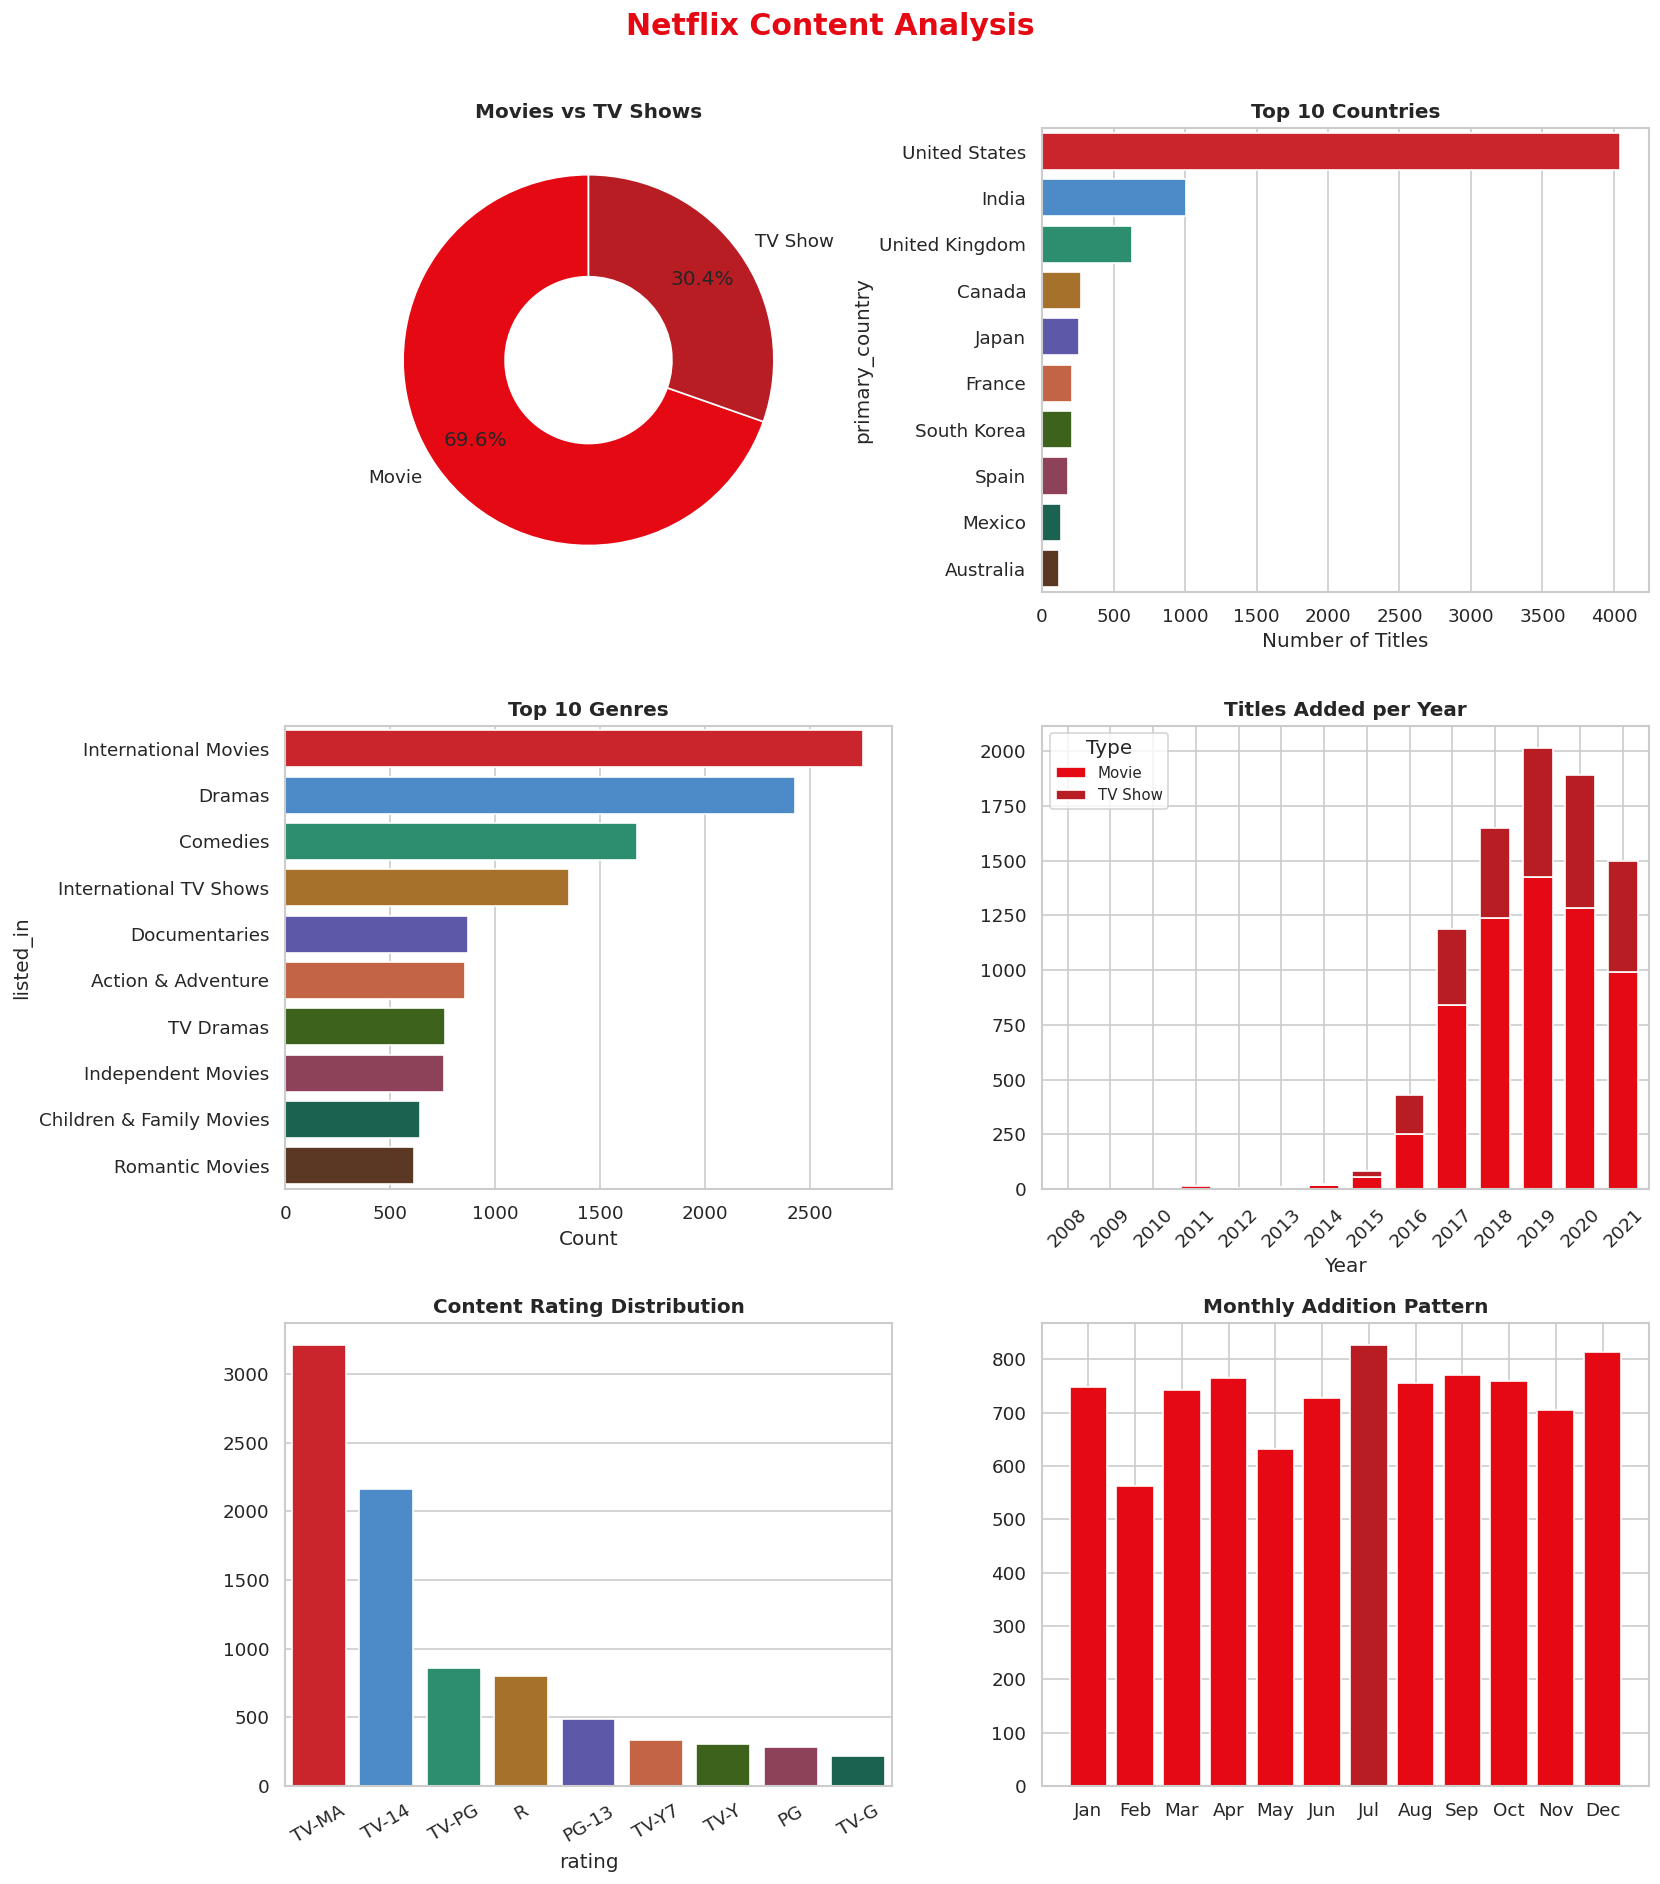

Plot saved as netflix_eda_plots.png


In [13]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('Netflix Content Analysis', fontsize=18,
             fontweight='bold', color=NETFLIX_RED, y=0.98)

# Plot 1 — Movies vs TV Shows
ax = axes[0, 0]
type_counts = df['type'].value_counts()
ax.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
       startangle=90, colors=[NETFLIX_RED, NETFLIX_DARK],
       wedgeprops=dict(width=0.55), pctdistance=0.75)
ax.set_title('Movies vs TV Shows', fontweight='bold')

# Plot 2 — Top 10 Countries
ax = axes[0, 1]
top_c = df['primary_country'].value_counts().head(10)
sns.barplot(x=top_c.values, y=top_c.index, palette=PALETTE, ax=ax)
ax.set_title('Top 10 Countries', fontweight='bold')
ax.set_xlabel('Number of Titles')

# Plot 3 — Top 10 Genres
ax = axes[1, 0]
genre_series = (df['listed_in'].str.split(',').explode()
                .str.strip().value_counts().head(10))
sns.barplot(x=genre_series.values, y=genre_series.index,
            palette=PALETTE, ax=ax)
ax.set_title('Top 10 Genres', fontweight='bold')
ax.set_xlabel('Count')

# Plot 4 — Content Added per Year
ax = axes[1, 1]
yearly = (df.groupby(['year_added', 'type'])['show_id']
            .count().unstack(fill_value=0))
yearly.plot(kind='bar', stacked=True, ax=ax,
            color=[NETFLIX_RED, NETFLIX_DARK], width=0.7)
ax.set_title('Titles Added per Year', fontweight='bold')
ax.set_xlabel('Year')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Type', fontsize=9)

# Plot 5 — Rating Distribution
ax = axes[2, 0]
ratings = df['rating'].value_counts().head(9)
sns.barplot(x=ratings.index, y=ratings.values,
            palette=PALETTE[:9], ax=ax)
ax.set_title('Content Rating Distribution', fontweight='bold')
ax.tick_params(axis='x', rotation=30)

# Plot 6 — Monthly Additions
ax = axes[2, 1]
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('month_name')['show_id'].count().reindex(month_order)
bar_colors = [NETFLIX_DARK if m == monthly.idxmax()
              else NETFLIX_RED for m in month_order]
ax.bar(month_order, monthly.values, color=bar_colors)
ax.set_title('Monthly Addition Pattern', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('netflix_eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved as netflix_eda_plots.png")